# 04 · Dotplot of Carrizo's two parents

Carrizo citrange is an F1 hybrid of sweet orange and *Poncirus trifoliata* (`README.md` §6.2), and there
is no Carrizo assembly, so every Carrizo gene has one copy from each parent. This notebook compares the
two parental assemblies we hold: **sweet orange DVS_A1.0** (GCF_022201045.2, the reference the CC galls
are aligned to; x axis) and ***Poncirus* ZK8** (GCA_018350135.1; y axis).

1. how much of each genome aligns to the other;
2. the whole-genome dotplot: which chromosomes pair, and where they are rearranged;
3. the chromosome pairing table;
4. how far apart the two parents are at the base level, genome-wide;
5. the same inside exons, which is what RNA-seq reads see, and how many reads from the *Poncirus* copy of
   each gene HISAT2 would reject when Carrizo is aligned to sweet orange alone.

Section 6 reads the result. Input: `references/plant_host/poncirus_trifoliata/citrus_sinensis__poncirus_trifoliata.paf`, written by
`sbatch scripts/dotplot.slurm` (minimap2 `-x asm20 -c`; a few minutes on 16 cores), and the matching
`.var.tsv` of base-level differences from `paftools.js call`. The script takes any
two hosts, and `TARGET` / `QUERY` below select the pair.

Run headless with
`~/.venvs/viz/bin/jupyter nbconvert --to notebook --execute --inplace notebooks/04_parent_dotplot.ipynb`
(see `notebooks/README.md`).

In [1]:
import re, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from IPython.display import display

sys.path.insert(0, str(Path.cwd()))
import gallrna_viz as gv

gv.use_theme()
ROOT = gv.ROOT

TARGET, QUERY = "citrus_sinensis", "poncirus_trifoliata"          # x axis, y axis
NAME = {"citrus_sinensis": "sweet orange DVS_A1.0", "poncirus_trifoliata": "Poncirus ZK8"}
MIN_BLOCK = 10_000       # bp; shorter alignment blocks are left out of the plots
FWD, REV = gv.SERIES[0], gv.SERIES[1]                             # same strand, opposite strand

PAF = ROOT / "references" / "plant_host" / QUERY / f"{TARGET}__{QUERY}.paf"
cols = ["q", "qlen", "qs", "qe", "strand", "t", "tlen", "ts", "te", "match", "alen", "mapq", "tp", "de"]
paf = pd.read_csv(PAF, sep="\t", names=cols)
paf["tp"] = paf["tp"].str[-1]                                     # P primary, S secondary
paf["de"] = paf["de"].str[5:].astype(float)                       # divergence per aligned base, gaps compressed
print(f"{PAF.relative_to(ROOT)}: {len(paf):,} blocks, {(paf.tp == 'P').sum():,} primary")

references/plant_host/poncirus_trifoliata/citrus_sinensis__poncirus_trifoliata.paf: 32,772 blocks, 21,774 primary


## 1. What aligned

Only the assembled chromosomes are used (both assemblies have nine; organelles and unplaced scaffolds are
dropped), and only primary alignments. Chromosome numbers come from the FASTA headers. Coverage is the
union of aligned intervals, so overlapping blocks are not counted twice.

In [2]:
def chromosomes(host):
    """contig accession -> 'chrN', for headers that say 'chromosome N'."""
    out = {}
    with open(ROOT / "references" / "plant_host" / host / f"{host}.fasta") as fh:
        for line in fh:
            if line[0] == ">":
                m = re.search(r"chromosome (\w+)", line)
                if m:
                    out[line[1:].split()[0]] = "chr" + m.group(1).rstrip(",")
    return out


def covered(starts, ends):
    """bp in the union of [start, end) intervals."""
    order = np.argsort(starts)
    s, e = np.asarray(starts)[order], np.asarray(ends)[order]
    reach = np.maximum.accumulate(e)
    new = np.r_[True, s[1:] > reach[:-1]]                         # interval opens a new island
    first = np.flatnonzero(new)
    last = np.r_[first[1:] - 1, len(s) - 1]
    return int((reach[last] - s[first]).sum())


tchr, qchr = chromosomes(TARGET), chromosomes(QUERY)
aln = paf[(paf.tp == "P") & paf.t.isin(tchr) & paf.q.isin(qchr)].copy()
aln["tc"], aln["qc"] = aln.t.map(tchr), aln.q.map(qchr)
tlen = aln.groupby("tc").tlen.first()
qlen = aln.groupby("qc").qlen.first()

summary = pd.DataFrame({
    "chromosomes, Mb": [tlen.sum() / 1e6, qlen.sum() / 1e6],
    "covered by an alignment, Mb": [sum(covered(g.ts, g.te) for _, g in aln.groupby("tc")) / 1e6,
                                    sum(covered(g.qs, g.qe) for _, g in aln.groupby("qc")) / 1e6],
}, index=[NAME[TARGET], NAME[QUERY]])
summary["covered, %"] = 100 * summary.iloc[:, 1] / summary.iloc[:, 0]
display(summary.round(1))

loose = paf[(paf.tp == "P") & paf.t.isin(tchr) & ~paf.q.isin(qchr)]
print(f"left out: {loose.q.nunique()} unplaced {NAME[QUERY]} scaffolds with {loose.alen.sum() / 1e6:.0f} Mb of primary "
      f"alignment to {NAME[TARGET]} chromosomes")
big = aln[aln.alen >= MIN_BLOCK]
print(f"{len(aln):,} primary chromosome-to-chromosome blocks; {len(big):,} are >= {MIN_BLOCK / 1e3:.0f} kb "
      f"and hold {100 * big.alen.sum() / aln.alen.sum():.0f}% of the aligned bases")

,"chromosomes, Mb","covered by an alignment, Mb","covered, %"
sweet orange DVS_A1.0,299.0,172.4,57.6
Poncirus ZK8,230.9,170.8,74.0


left out: 447 unplaced Poncirus ZK8 scaffolds with 54 Mb of primary alignment to sweet orange DVS_A1.0 chromosomes
14,303 primary chromosome-to-chromosome blocks; 5,729 are >= 10 kb and hold 85% of the aligned bases


## 2. The dotplot

Each line is one alignment block: x = position in sweet orange, y = position in *Poncirus*. A diagonal
rising to the right is collinear sequence; a line falling to the right is on the opposite strand (an
inversion, or simply a chromosome that the two projects assembled in opposite orientations). *Poncirus*
chromosomes are ordered by the sweet-orange chromosome they share the most sequence with, so the pairing
reads along the diagonal whatever the two numbering schemes are. Nothing is flipped.

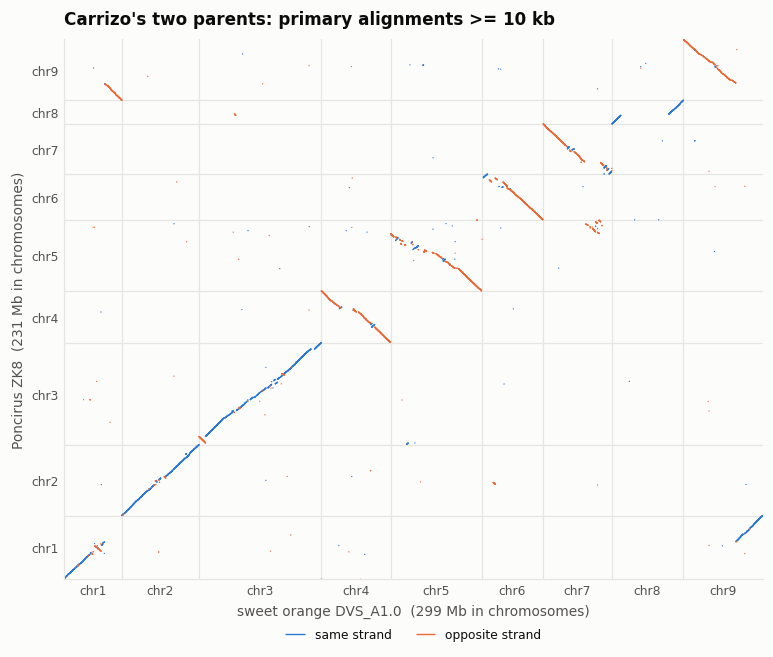

In [3]:
# pair every query chromosome with the target chromosome holding most of its aligned bases
share = big.groupby(["qc", "tc"]).alen.sum().unstack(fill_value=0)
natural = lambda names: sorted(names, key=lambda c: (len(c), c))
torder = natural(tlen.index)
best = share.idxmax(axis=1)
qorder = sorted(qlen.index, key=lambda c: (torder.index(best[c]), c))

toff = pd.Series(np.r_[0, tlen[torder].cumsum().values[:-1]], index=torder)
qoff = pd.Series(np.r_[0, qlen[qorder].cumsum().values[:-1]], index=qorder)


def dotplot(ax, blocks, toff, qoff, lw=0.9):
    x0 = blocks.ts.values + blocks.tc.map(toff).values
    x1 = blocks.te.values + blocks.tc.map(toff).values
    fwd = (blocks.strand == "+").values
    y0 = np.where(fwd, blocks.qs.values, blocks.qe.values) + blocks.qc.map(qoff).values
    y1 = np.where(fwd, blocks.qe.values, blocks.qs.values) + blocks.qc.map(qoff).values
    seg = np.stack([np.c_[x0, y0], np.c_[x1, y1]], axis=1) / 1e6
    for mask, color, label in ((fwd, FWD, "same strand"), (~fwd, REV, "opposite strand")):
        ax.add_collection(LineCollection(seg[mask], colors=color, linewidths=lw, label=label,
                                         capstyle="round"))


fig, ax = plt.subplots(figsize=(8.2, 8.2))
dotplot(ax, big, toff, qoff)
tend, qend = (toff + tlen[torder]) / 1e6, (qoff + qlen[qorder]) / 1e6
ax.set_xlim(0, tend.iloc[-1]); ax.set_ylim(0, qend.iloc[-1])
ax.set_xticks(tend.values[:-1], minor=False); ax.set_yticks(qend.values[:-1], minor=False)   # chromosome borders
ax.tick_params(labelbottom=False, labelleft=False, length=0)
ax.grid(True, color=gv.GRID, linewidth=0.8)
ax.set_xticks((toff / 1e6 + tlen[torder] / 2e6).values, torder, minor=True)                  # names at mid-chromosome
ax.set_yticks((qoff / 1e6 + qlen[qorder] / 2e6).values, qorder, minor=True)
ax.tick_params(which="minor", length=0, labelsize=8)
ax.grid(False, which="minor")
ax.set_xlabel(f"{NAME[TARGET]}  ({tlen.sum() / 1e6:.0f} Mb in chromosomes)")
ax.set_ylabel(f"{NAME[QUERY]}  ({qlen.sum() / 1e6:.0f} Mb in chromosomes)")
ax.set_title(f"Carrizo's two parents: primary alignments >= {MIN_BLOCK / 1e3:.0f} kb")
ax.set_aspect("equal")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), ncols=2, handlelength=1.6)
fig.savefig(gv.FIGDIR / "30_parent_dotplot.png")
plt.show()

## 3. Chromosome pairing

For each *Poncirus* chromosome: its sweet-orange partner, how much of its aligned sequence sits on that
partner, and how much of that is on the opposite strand. A chromosome that is almost entirely
"opposite strand" was assembled in the other orientation, which is an assembly convention, not biology;
inversions are the opposite-strand stretches inside an otherwise same-strand chromosome (or the reverse).

In [4]:
rows = []
for qc in qorder:
    g = big[big.qc == qc]
    on = g[g.tc == best[qc]]
    rows.append({f"{NAME[QUERY]}": qc, "length, Mb": qlen[qc] / 1e6,
                 f"partner in {NAME[TARGET]}": best[qc], "partner length, Mb": tlen[best[qc]] / 1e6,
                 "aligned bases on partner, %": 100 * on.alen.sum() / g.alen.sum(),
                 "of those, opposite strand, %": 100 * on.alen[on.strand == "-"].sum() / on.alen.sum(),
                 "divergence on partner, %": 100 * np.average(on.de, weights=on.alen)})
pairing = pd.DataFrame(rows).set_index(f"{NAME[QUERY]}")
display(pairing.round(1))

,"length, Mb",partner in sweet orange DVS_A1.0,"partner length, Mb","aligned bases on partner, %","of those, opposite strand, %","divergence on partner, %"
Poncirus ZK8,,,,,,
chr1,27.3,chr1,24.8,56.4,18.2,4.1
chr2,30.3,chr2,32.9,96.6,3.7,4.0
chr3,43.7,chr3,52.3,98.1,11.3,4.0
chr4,22.2,chr4,29.6,99.7,88.0,3.8
chr5,30.3,chr5,39.0,84.9,84.5,3.7
chr6,19.6,chr6,26.2,99.2,89.8,4.0
chr7,21.5,chr7,29.5,99.4,79.5,3.8
chr8,10.1,chr8,30.6,95.2,0.0,3.8
chr9,26.0,chr9,34.0,67.8,95.8,4.1


## 4. How far apart are the parents?

`de` is minimap2's divergence per aligned base with each gap counted once. Weighted by block length, it
is the average distance between the *Poncirus* copy and the sweet-orange copy of whatever aligned.
It matters here because the Carrizo galls are aligned to sweet orange only: a read from a *Poncirus*
copy carries about this many extra mismatches, and HISAT2 drops reads past roughly 5 per 150 bp
(`README.md` step 5b).

divergence, weighted by aligned length: mean 4.17%, median 3.81% (10th-90th percentile 2.81-5.75%)
expected mismatches in a 150 bp read from the Poncirus copy: about 5.7 at the median


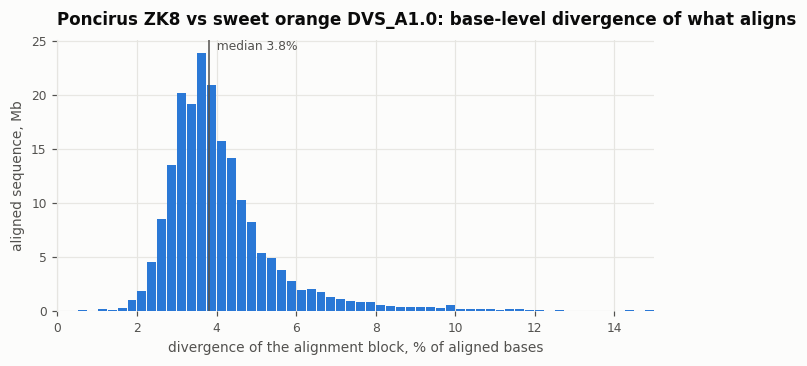

In [5]:
w = aln.alen.values
order = np.argsort(aln.de.values)
cum = np.cumsum(w[order]) / w.sum()
q = {p: 100 * aln.de.values[order][np.searchsorted(cum, p)] for p in (0.1, 0.5, 0.9)}
mean = 100 * np.average(aln.de, weights=w)
print(f"divergence, weighted by aligned length: mean {mean:.2f}%, median {q[0.5]:.2f}% "
      f"(10th-90th percentile {q[0.1]:.2f}-{q[0.9]:.2f}%)")
print(f"expected mismatches in a 150 bp read from the Poncirus copy: about {1.5 * q[0.5]:.1f} at the median")

fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.arange(0, 15.25, 0.25)
ax.hist(100 * aln.de, bins=bins, weights=w / 1e6, color=FWD, rwidth=0.9)
ax.axvline(q[0.5], color=gv.INK2, linewidth=1)
ax.text(q[0.5], ax.get_ylim()[1], f"  median {q[0.5]:.1f}%", va="top", fontsize=8, color=gv.INK2)
ax.set_xlim(0, 15)
ax.set_xlabel("divergence of the alignment block, % of aligned bases")
ax.set_ylabel("aligned sequence, Mb")
ax.set_title(f"{NAME[QUERY]} vs {NAME[TARGET]}: base-level divergence of what aligns")
gv.clean(ax, "y")
fig.savefig(gv.FIGDIR / "31_parent_divergence.png")
plt.show()

## 5. What RNA-seq reads see: exons

The 3.8% above is mostly intergenic and intronic sequence. `paftools.js call` lists every difference
between the two assemblies inside regions covered by exactly one alignment, so the rate can be taken per
annotation class. Then the question that matters for the counts: take 150 bp windows along each gene's
exons, as stand-ins for reads from the *Poncirus* copy, and score each window's differences the way
HISAT2 does (6 per mismatch, 5 + 3 per base for a gap; a read scoring below -30 is not aligned). It is an
upper bound on the loss: HISAT2 can also soft-clip differences near a read end, and a pair is still
counted when only one mate aligns.

In [6]:
VAR = PAF.with_suffix(".var.tsv")
var = pd.read_csv(VAR, sep="\t", names=["kind", "c", "s", "e", "ilen"])
var = var[var.c.isin(tchr)]
uniq, diff = var[var.kind == "R"], var[var.kind == "V"].sort_values(["c", "s"])
diff = diff.assign(sub=(diff.ilen == 0).astype(int), indel=(diff.ilen > 0).astype(int),
                   pen=np.where(diff.ilen == 0, 6, 5 + 3 * diff.ilen))
index = {c: (g.s.values, {k: np.r_[0, np.cumsum(g[k].values)] for k in ("sub", "indel", "pen")})
         for c, g in diff.groupby("c")}


def tally(c, s, e, what):
    """sum of `what` over differences in [s, e); s and e may be arrays."""
    pos, cs = index[c]
    return cs[what][np.searchsorted(pos, e, "left")] - cs[what][np.searchsorted(pos, s, "left")]


def merge(iv):
    out = []
    for s, e in sorted(iv):
        if out and s <= out[-1][1]:
            out[-1][1] = max(out[-1][1], e)
        else:
            out.append([s, e])
    return out


def intersect(a, b):
    i = j = 0
    out = []
    while i < len(a) and j < len(b):
        s, e = max(a[i][0], b[j][0]), min(a[i][1], b[j][1])
        if s < e:
            out.append([s, e])
        if a[i][1] < b[j][1]:
            i += 1
        else:
            j += 1
    return out


def subtract(a, b):
    return intersect(a, [[s, e] for s, e in zip([0] + [x[1] for x in b], [x[0] for x in b] + [10**10]) if s < e])


# protein-coding genes, their exons and CDS, from the GFF the galls are counted on
from collections import defaultdict
feat = {k: defaultdict(list) for k in ("gene", "exon", "CDS")}
gene_exons, parent = defaultdict(list), {}
with open(ROOT / "references" / "plant_host" / TARGET / f"{TARGET}.gff3") as fh:
    for line in fh:
        f = line.rstrip("\n").split("\t")
        if len(f) < 9 or f[0] not in tchr:
            continue
        a = dict(x.split("=", 1) for x in f[8].split(";") if "=" in x)
        s, e = int(f[3]) - 1, int(f[4])
        if f[2] == "gene" and a.get("gene_biotype") == "protein_coding":
            feat["gene"][f[0]].append((s, e)); parent[a["ID"]] = a["ID"]
        elif f[2] == "mRNA" and a.get("Parent") in parent:
            parent[a["ID"]] = a["Parent"]
        elif f[2] in ("exon", "CDS") and a.get("Parent") in parent:
            feat[f[2]][f[0]].append((s, e))
            if f[2] == "exon":
                gene_exons[(f[0], parent[a["Parent"]])].append((s, e))

once = {c: merge(zip(g.s, g.e)) for c, g in uniq.groupby("c")}
rows = []
for name in ("coding sequence", "exons, UTRs included", "introns", "intergenic"):
    bp = ns = ni = 0
    for c in once:
        gene, exon, cds = (merge(feat[k][c]) for k in ("gene", "exon", "CDS"))
        iv = {"coding sequence": cds, "exons, UTRs included": exon, "introns": subtract(gene, exon),
              "intergenic": subtract([[0, 10**10]], gene)}[name]
        iv = np.array(intersect(iv, once[c]))
        bp += (iv[:, 1] - iv[:, 0]).sum()
        ns += tally(c, iv[:, 0], iv[:, 1], "sub").sum(); ni += tally(c, iv[:, 0], iv[:, 1], "indel").sum()
    rows.append({"region": name, "uniquely aligned, Mb": bp / 1e6, "substitutions per 100 bp": 100 * ns / bp,
                 "indels per kb": 1000 * ni / bp})
by_region = pd.DataFrame(rows).set_index("region")
display(by_region.round(2))

,"uniquely aligned, Mb",substitutions per 100 bp,indels per kb
region,,,
coding sequence,26.87,1.50,0.40
"exons, UTRs included",36.97,1.80,1.76
introns,39.71,2.51,3.93
intergenic,99.74,3.73,5.50


948,480 windows in 19,223 of 23,436 protein-coding genes (82%; the rest have no uniquely aligned exon of 150 bp)
identical in both parents 14.7%   alignable 78.5%   rejected 21.5%
if half of Carrizo's reads come from the Poncirus copy, about 11% of all reads are lost: a 92% library (Hamlin) would align at about 82%. Observed for the Carrizo galls: 82-85%.
per gene: median 19% of Poncirus-copy reads rejected; >25% in 38.7% of genes; >50% in 12.2% of genes; >90% in 2.1% of genes
wrote 04_matrix/carrizo_poncirus_read_loss.tsv


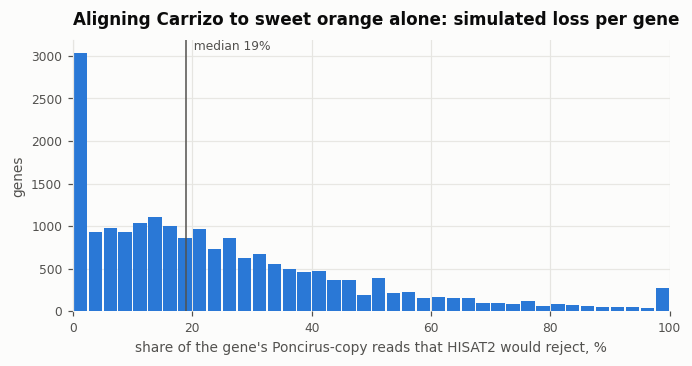

In [7]:
READ, STEP, LIMIT = 150, 25, 30          # read length; window step; HISAT2 --score-min L,0,-0.2 at 150 bp
lost, penalties = {}, []
for (c, gene), ex in gene_exons.items():
    starts = [np.arange(s, e - READ + 1, STEP) for s, e in intersect(merge(ex), once.get(c, [])) if e - s >= READ]
    if starts:
        starts = np.concatenate(starts)
        pen = tally(c, starts, starts + READ, "pen")
        penalties.append(pen); lost[gene] = (pen > LIMIT).mean()
penalties = np.concatenate(penalties)
lost = pd.Series(lost, name="poncirus_reads_rejected").rename_axis("gene_id")
n_genes = sum(len(v) for v in feat["gene"].values())

rejected = (penalties > LIMIT).mean()
print(f"{len(penalties):,} windows in {len(lost):,} of {n_genes:,} protein-coding genes "
      f"({100 * len(lost) / n_genes:.0f}%; the rest have no uniquely aligned exon of {READ} bp)")
print(f"identical in both parents {100 * (penalties == 0).mean():.1f}%   alignable {100 * (1 - rejected):.1f}%   "
      f"rejected {100 * rejected:.1f}%")
print(f"if half of Carrizo's reads come from the Poncirus copy, about {100 * rejected / 2:.0f}% of all reads are lost: "
      f"a 92% library (Hamlin) would align at about {92 * (1 - rejected / 2):.0f}%. Observed for the Carrizo galls: 82-85%.")
print(f"per gene: median {100 * lost.median():.0f}% of Poncirus-copy reads rejected; "
      + "; ".join(f">{int(100 * x)}% in {100 * (lost > x).mean():.1f}% of genes" for x in (0.25, 0.5, 0.9)))

OUT = ROOT / "04_matrix" / "carrizo_poncirus_read_loss.tsv"
lost.to_csv(OUT, sep="\t", float_format="%.3f")
print("wrote", OUT.relative_to(ROOT))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(100 * lost, bins=np.arange(0, 102.5, 2.5), color=FWD, rwidth=0.9)
ax.axvline(100 * lost.median(), color=gv.INK2, linewidth=1)
ax.text(100 * lost.median(), ax.get_ylim()[1], f"  median {100 * lost.median():.0f}%", va="top", fontsize=8, color=gv.INK2)
ax.set_xlim(0, 100)
ax.set_xlabel("share of the gene's Poncirus-copy reads that HISAT2 would reject, %")
ax.set_ylabel("genes")
ax.set_title("Aligning Carrizo to sweet orange alone: simulated loss per gene")
gv.clean(ax, "y")
fig.savefig(gv.FIGDIR / "33_parent_read_loss.png")
plt.show()

## 6. What it shows (run of 2026-09-17)

- **The nine chromosomes pair one to one, with the same numbers in both assemblies**, and are collinear
  along most of their length. 172 Mb of sweet orange's 299 Mb of chromosomes (58%) and 171 Mb of
  *Poncirus*'s 231 Mb (74%) sit in an alignment. The gaps are mid-chromosome, where repeat-rich sequence
  is expected; the gene-rich arms align almost end to end.
- **Orientation is an assembly convention.** *Poncirus* chr4, chr5, chr6, chr7 and chr9 are 80-96%
  opposite strand: those chromosomes were simply assembled the other way round. The inversions are the
  short stretches that break the prevailing colour, e.g. on chr1 (13-16 Mb in sweet orange, section 7),
  chr3, chr5 and chr7.
- **Two exchanges between chromosomes.** The far end of *Poncirus* chr1 aligns to the end of sweet orange
  chr9 (8.5 Mb of alignment) and the start of *Poncirus* chr9 aligns to sweet orange chr1 (5.1 Mb): a
  reciprocal exchange between chr1 and chr9. *Poncirus* chr5 also carries a 2.9 Mb block of sweet orange
  chr7. Two assemblies can't say whether these are real translocations or a scaffolding difference in
  one of them. If real, Carrizo is heterozygous for them.
- ***Poncirus* chr8 is short (10 Mb against 31 Mb)** and covers only the two ends of sweet orange chr8.
  The middle (3.8-24.3 Mb) isn't missing from *Poncirus*: it aligns to ZK8's unplaced scaffolds (14 Mb
  of alignment), so that part of chr8 was never scaffolded in this copy of ZK8. Overall the unplaced
  scaffolds carry 54 Mb of alignment. For the two-parent Carrizo reference (`README.md` §8.2 A) this
  means the scaffolds must stay in the reference, and gene order on chr8 can't be read from ZK8.
- **Genome-wide the parents differ at about 4% of aligned bases** (median 3.8%, 10th-90th percentile
  2.8-5.8%), evenly across chromosomes. But that is mostly non-coding sequence.
- **Genes are far better conserved than the genome.** With the unplaced scaffolds counted, 67% of the
  sweet-orange chromosomes but 85% of exon sequence and 87% of coding sequence has a *Poncirus*
  counterpart. Substitutions run at 1.5 per 100 bp in coding sequence and 1.8 in exons, against 2.5 in
  introns and 3.7 between genes; indels are ten times rarer in coding sequence than between genes.
- **Aligning Carrizo to sweet orange alone costs about a fifth of the *Poncirus*-copy reads, a tenth of
  all reads.** 21.5% of simulated *Poncirus*-copy reads exceed HISAT2's limit. With half the reads from
  each copy that predicts ~82% alignment for a library that would otherwise reach 92%, and the Carrizo
  galls align at 82-85% (`README.md` step 5b). The whole-genome 58% is not the relevant number.
- **The loss is uneven across genes.** The median gene loses 19% of its *Poncirus*-copy reads (about 10%
  of its count, -0.15 log2). 12% of genes lose more than half (count down by a quarter or more) and 2%
  lose nearly all, so their Carrizo count is the sweet-orange copy alone (-1 log2). 18% of genes have no
  uniquely aligned exon and can't be scored: multi-copy families, genes on sequence that is missing or
  too diverged in ZK8. `04_matrix/carrizo_poncirus_read_loss.tsv` has the figure per gene, to flag
  shortlist candidates.
- **What this does and doesn't affect.** The bias is identical in every Carrizo library, galls and
  Carrizo baselines alike, so Carrizo-vs-Carrizo comparisons are unaffected. It does bias Carrizo galls
  against *pure sweet-orange* tissue (the bark and callus baselines) downwards for the diverged genes,
  and it hides *Poncirus*-only genes and any difference between the two copies. Those are the cases the
  two-parent reference (`README.md` section 8.2 A) is for.

## 7. One chromosome pair, close up

Set `ZOOM` to any *Poncirus* chromosome; its partner is looked up. Shorter blocks are kept here
(`>= 2 kb`), since one pair has room for them.

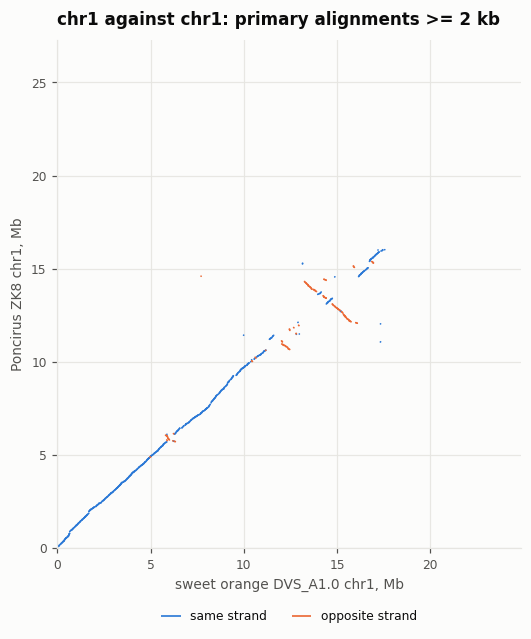

In [8]:
ZOOM = qorder[0]
pair = aln[(aln.qc == ZOOM) & (aln.tc == best[ZOOM]) & (aln.alen >= 2_000)]
zero = pd.Series({best[ZOOM]: 0}), pd.Series({ZOOM: 0})

fig, ax = plt.subplots(figsize=(6, 6))
dotplot(ax, pair, *zero, lw=1.1)
ax.set_xlim(0, tlen[best[ZOOM]] / 1e6); ax.set_ylim(0, qlen[ZOOM] / 1e6)
ax.set_xlabel(f"{NAME[TARGET]} {best[ZOOM]}, Mb"); ax.set_ylabel(f"{NAME[QUERY]} {ZOOM}, Mb")
ax.set_title(f"{ZOOM} against {best[ZOOM]}: primary alignments >= 2 kb")
ax.set_aspect("equal")
gv.clean(ax, "both")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncols=2, handlelength=1.6)
fig.savefig(gv.FIGDIR / f"32_parent_dotplot_{ZOOM}.png")
plt.show()